# Rigid landmark registration in SE(2)

Rigid registration estimates the rotation and translation that align two
matched point sets. It appears in medical-image registration, microscopy,
robot perception, and shape analysis. Working in two dimensions makes every
part of the fit visible while retaining the same geometry used in higher
dimensions.

The special Euclidean group is

$$
\operatorname{SE}(2)
=\left\{
G=\begin{bmatrix}R&t\\0&1\end{bmatrix}:
R\in\operatorname{SO}(2),\ t\in\mathbb R^2
\right\}.
$$

It acts on a landmark $p\in\mathbb R^2$ by $G\cdot p=Rp+t$. Given matched
source and target landmarks $p_i$ and $q_i$, we minimize

$$
F(G)=\frac{1}{2N}\sum_{i=1}^N
\lVert G\cdot p_i-q_i\rVert_2^2,
\qquad G\in\operatorname{SE}(2).
$$

Optimizing directly on `SpecialEuclidean` keeps the rotation orthogonal with
determinant one at every iteration; no rotation penalty is needed.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import SpecialEuclidean
from geojax.optimization import ConjugateGradient, Minimize

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def rotation(theta):
    c, s = jnp.cos(theta), jnp.sin(theta)
    return jnp.array([[c, -s], [s, c]])


M = SpecialEuclidean(size=2)

source = jnp.array([
    [-1.10, -0.45],
    [-0.55,  0.80],
    [ 0.15,  0.55],
    [ 0.95,  0.90],
    [ 1.15, -0.50],
    [ 0.10, -0.85],
])

ground_truth = M.from_components(
    rotation(0.62),
    jnp.array([0.85, -0.30]),
)

clean_target = jax.vmap(lambda point: M.apply(ground_truth, point))(source)
measurement_noise = jnp.array([
    [ 0.015, -0.010],
    [-0.020,  0.015],
    [ 0.010,  0.020],
    [ 0.018, -0.016],
    [-0.012, -0.018],
    [-0.008,  0.012],
])
target = clean_target + measurement_noise

## Fit the rigid motion

The public point is a $3\times3$ homogeneous matrix. `M.apply` evaluates its
action without asking the objective to unpack that representation.

In [2]:
def transform(G, points):
    return jax.vmap(lambda point: M.apply(G, point))(points)


def cost(G):
    residual = transform(G, source) - target
    return 0.5 * jnp.mean(jnp.sum(residual * residual, axis=-1))


x0 = M.from_components(
    rotation(-0.25),
    jnp.array([-0.35, 0.25]),
)

problem = Minimize(
    M=M,
    cost=cost,
    x0=x0,
    solver=ConjugateGradient(maxiter=120, tolgradnorm=1e-10, verbosity=0),
)
estimate, final_cost, history = problem.solve()

R_hat = M.rotation(estimate)
t_hat = M.translation(estimate)
angle_hat = jnp.arctan2(R_hat[1, 0], R_hat[0, 0])

print(f"estimated angle      : {float(angle_hat): .5f} rad")
print(f"estimated translation: {np.asarray(t_hat)}")
print(f"final mean loss      : {final_cost:.6e}")
print(f"distance from truth  : {float(M.dist(estimate, ground_truth)):.3e}")
print(f"iterations           : {history[-1].iter}")
print(f"termination          : {history[-1].reason}")

estimated angle      :  0.61407 rad
estimated translation: [ 0.84973703 -0.29919311]
final mean loss      : 2.060113e-04
distance from truth  : 8.428e-03
iterations           : 35
termination          : Last stepsize smaller than options.minstepsize = 1e-10.


Because the targets contain measurement noise, the least-squares estimate is
close to, but not exactly equal to, the generating transformation.

## Visual report

The first panel shows the deliberately poor initialization. The second compares
the registered landmarks with the observations and draws each residual. The
last panel reports the objective decrease.

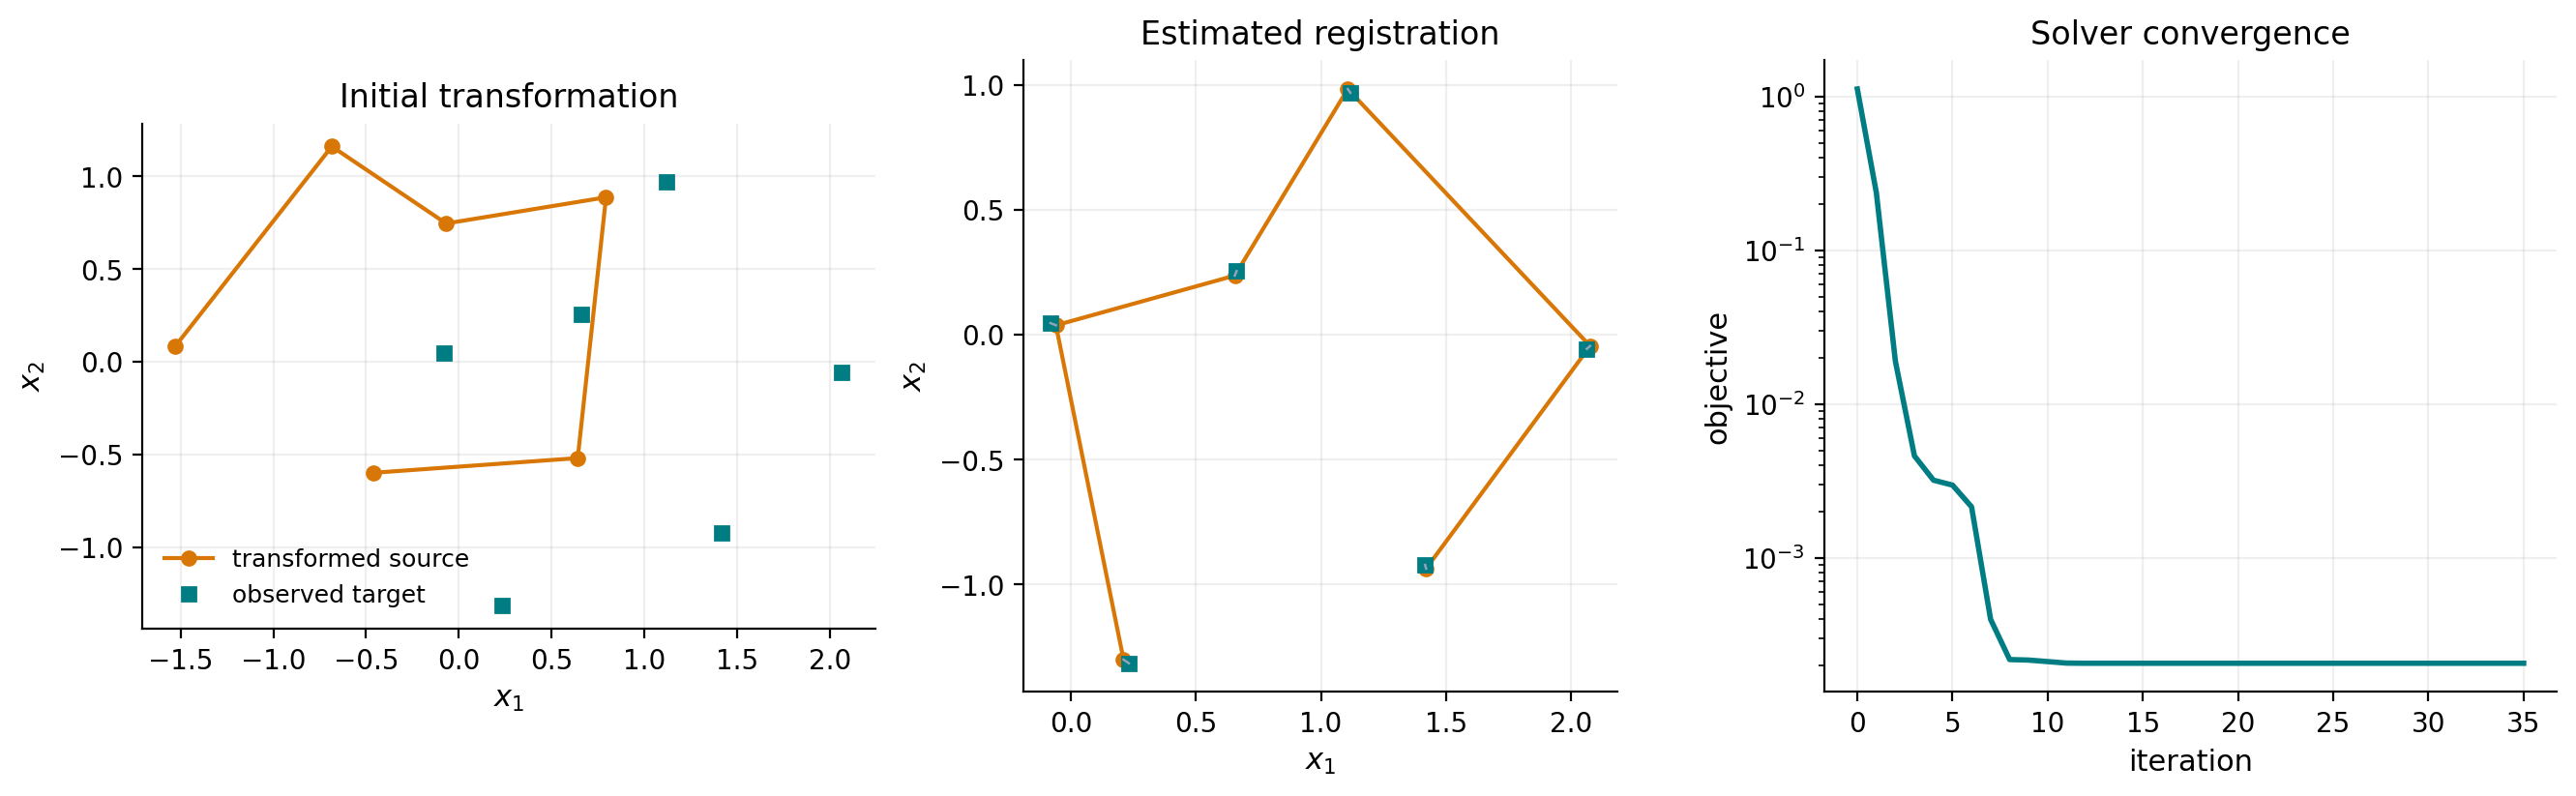

In [3]:
initial = transform(x0, source)
aligned = transform(estimate, source)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), constrained_layout=True)

def landmark_panel(ax, moved, title, show_residuals=False):
    ax.plot(
        moved[:, 0], moved[:, 1], "o-", color="#D97706",
        linewidth=1.5, markersize=5, label="transformed source",
    )
    ax.plot(
        target[:, 0], target[:, 1], "s", color="#007C83",
        markersize=5, label="observed target",
    )
    if show_residuals:
        for estimate_i, target_i in zip(np.asarray(moved), np.asarray(target)):
            ax.plot(
                [estimate_i[0], target_i[0]], [estimate_i[1], target_i[1]],
                color="#94A3B8", linewidth=0.9,
            )
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
    ax.grid(alpha=0.2)


landmark_panel(axes[0], initial, "Initial transformation")
axes[0].legend(frameon=False, fontsize=9)
landmark_panel(axes[1], aligned, "Estimated registration", show_residuals=True)

iterations = np.arange(len(history))
costs = np.maximum([entry.cost for entry in history], 1e-16)
axes[2].semilogy(iterations, costs, color="#007C83", linewidth=2)
axes[2].set(title="Solver convergence", xlabel="iteration", ylabel="objective")
axes[2].grid(alpha=0.2)

plt.show()

`SpecialOrthogonal` can be used alone when translation is known or absent.
For pose interpolation and kinematics, note that `SpecialEuclidean.exp` is the
Riemannian exponential of the canonical product metric, while
`SpecialEuclidean.group_exp` is the coupled matrix-group exponential. The
[geometry guide](../guide/geometry.md) states both formulas explicitly.